# Notebook 01: Data Loading & Cleaning

## Contexto

Este notebook carga los datos brutos del sistema de prospecting de **Raona** (Microsoft Gold Partner), 
crea la variable objetivo y guarda un dataset limpio en formato Parquet.

### Elección de la tabla base

El sistema Enginy exporta dos tablas principales:

| Tabla | Granularidad | Filas | ID |
|-------|-------------|-------|------|
| `conversation_level_analytics_ES.csv` | Una fila por conversación (campaña x contacto) | 11,517 | `contactId` (numerico interno) |
| `contacts_table_ES.csv` | Una fila por contacto único | 11,095 | `LinkedIn profile ID` |

**Problema:** El `contactId` de analytics es un ID interno de Enginy que no existe en ninguna otra tabla exportada. 
El join directo entre analytics y contacts produce **0% de match**.

**Solución:** Usamos `contacts_table_ES.csv` como tabla base. Contiene:
- Todos los datos de contacto y empresa (373 columnas, selecciónamos las relevantes para el proyecto)
- El campo `Campaign engagement status` que indica si el contacto respondió
- La granularidad correcta para la pregunta de negocio: **quien debemos contactar** (no que conversación respondió)

Los datos de `conversation_level_analytics` y `daily_comprehensive_analytics` se guardan por separado 
para análisis de funnel, timing y canal en NB02.

**Regla fundamental:** En este notebook solo cargamos columnas originales. No creamos features nuevas 
(eso se hace en NB03). Las columnas generadas por IA de Raona se renombran con prefijo `ai_` para trazabilidad.

## Archivos de entrada

| Archivo | Contenido | Filas |
|---------|-----------|-------|
| `contacts_table_ES.csv` | Perfiles de contactos + datos empresa (373 columnas) | 11,095 |
| `conversation_level_analytics_ES.csv` | Métricas por conversación de outreach | 11,517 |
| `daily_comprehensive_analytics_ES.csv` | Métricas diarias agregadas | 310 |
| `replies_analytics_ES.csv` | Respuestas mensuales por canal | 18 |

## Imports y Configuración

In [1]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

# Rutas
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
RAW_DATA = os.path.join(PROJECT_ROOT, '..', 'raw_data')
WORKING_DATA = os.path.join(PROJECT_ROOT, '..', '_working', 'data')

# Verificar que existen los directorios
assert os.path.exists(RAW_DATA), f'No se encuentra raw_data en {RAW_DATA}'
os.makedirs(WORKING_DATA, exist_ok=True)

print(f'RAW_DATA: {RAW_DATA}')
print(f'WORKING_DATA: {WORKING_DATA}')
print(f'Archivos disponibles: {sorted(os.listdir(RAW_DATA))}')

RAW_DATA: /Users/acaballito/Library/CloudStorage/GoogleDrive-adriana.caballero@gmail.com/.shortcut-targets-by-id/1LzrxzfxIAZukyDLfOvioF7Z2ESoOXZGz/TFM/acaballero/TFM_deliverables/../raw_data
WORKING_DATA: /Users/acaballito/Library/CloudStorage/GoogleDrive-adriana.caballero@gmail.com/.shortcut-targets-by-id/1LzrxzfxIAZukyDLfOvioF7Z2ESoOXZGz/TFM/acaballero/TFM_deliverables/../_working/data
Archivos disponibles: ['companies_table_ES.csv', 'contacts_table_ES.csv', 'conversation_level_analytics_ES.csv', 'conversations_table_ES.csv', 'daily_comprehensive_analytics_ES.csv', 'replies_analytics_ES.csv']


---
## 1.1 Cargar contacts_table_ES (tabla base)

El archivo `contacts_table_ES.csv` tiene 373 columnas. Solo cargamos las 43 que necesitamos 
usando `usecols` para eficiencia de memoria.

### Convencion de nombres:
- Columnas originales de datos: se mantienen tal cual
- Columnas generadas por la IA de Raona: se renombran con prefijo `ai_`

In [2]:
# Columnas que necesitamos de contacts_table
CONTACT_COLS = [
    # Identificadores
    'LinkedIn profile ID', 'Company URN', 'Company name',
    # Engagement (para construir target)
    'Campaign engagement status', 'Conversation tags', 'Campaigns',
    # Datos demograficos del contacto (RAW)
    'First name', 'Last name', 'Full name',
    'Job title', 'Years in role', 'Years in company',
    'Number of connections', 'Contact country', 'Geo region',
    'Profile bio', 'Professional email',
    # Generados por IA de Raona (se renombraran con ai_)
    'SENIORITY', 'DEPARTMENT',
    'FIT', 'FIT IA', 'FIT COLABORA',
    'FIT DATA',
    # TYPE OF CONTACT: tipo de contacto por linea de producto
    'TYPE OF CONTACT',
    'TYPE OF CONTACT COLABORA', 'TYPE OF CONTACT IA',
    'TYPE OF CONTACT INFRA', 'TYPE OF CONTACT MAITE',
    'TYPE OF CONTACT WORKPLACE', 'TYPE OF CONTACT DATA',
    # Campos de texto (para NLP en NB03)
    'CONTACT REPORT', 'COMPANY REPORT', 'MOMENTUM',
    # Datos de empresa
    'Industry', 'Number of employees', 'Year founded',
    'Hiring on LinkedIn',
    'Six months headcount growth', 'Two years headcount growth', 'Yearly headcount growth',
    # Tecnologia
    'Technologies used', 'Microsoft?',
    # LinkedIn activity
    'Last LinkedIn post date',
]

print(f'Cargando {len(CONTACT_COLS)} columnas de contacts_table_ES.csv...')

Cargando 43 columnas de contacts_table_ES.csv...


In [3]:
%%time

df = pd.read_csv(
    os.path.join(RAW_DATA, 'contacts_table_ES.csv'),
    usecols=CONTACT_COLS,
    encoding='utf-8-sig',
    low_memory=False
)

print(f'Contactos cargados: {len(df):,} filas x {len(df.columns)} columnas')
print(f'Memoria: {df.memory_usage(deep=True).sum() / 1e6:.0f} MB')

Contactos cargados: 11,095 filas x 43 columnas
Memoria: 262 MB
CPU times: user 2.08 s, sys: 640 ms, total: 2.72 s
Wall time: 2.97 s


In [4]:
# Inspeccion rapida
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11095 entries, 0 to 11094
Data columns (total 43 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   LinkedIn profile ID          10965 non-null  object 
 1   First name                   10311 non-null  object 
 2   Job title                    10232 non-null  object 
 3   Last name                    10307 non-null  object 
 4   Professional email           6334 non-null   object 
 5   Geo region                   10189 non-null  object 
 6   Contact country              5998 non-null   object 
 7   Profile bio                  5182 non-null   object 
 8   Years in company             8581 non-null   float64
 9   Years in role                9038 non-null   float64
 10  Number of connections        10188 non-null  float64
 11  Last LinkedIn post date      404 non-null    object 
 12  TYPE OF CONTACT COLABORA     9326 non-null   object 
 13  TYPE OF CONTACT 

In [5]:
df.head(3)

,LinkedIn profile ID,First name,Job title,Last name,Professional email,Geo region,Contact country,Profile bio,Years in company,Years in role,...,Six months headcount growth,Two years headcount growth,Yearly headcount growth,FIT IA,Microsoft?,FIT,FIT COLABORA,FIT DATA,COMPANY REPORT,MOMENTUM
0,ACwAAAv4pNQBpWYBivXa_19-rsmRBRvYnYM4rNw,Felipe A.,Project Manager (PMO),Barragan Lorda,NaN,Greater Sevilla Metropolitan Area,NaN,NaN,23.08,16.42,...,NaN,10.0,6.0,NaN,1.0,🟢 APROBADO + 9\n\nPor qué hay fit\n\n- Ubicaci...,NaN,SI,Informe ejecutivo (resumido y accionable) sobr...,Ebro Foods S.A. is the leading food company in...
1,ACwAAB3TkQEB_7X3MtxRi26VQT-76ICCyPwplJ4,Alvaro,Project Manager (PMO),GARCIA CID,agarciacid@aertecsolutions.com,Spain,Spain,Tras varios años de experiencia profesional en...,2.42,2.42,...,NaN,4.0,-5.0,🟢 APROBADO + 9\n\n**Análisis de Fit con AERTEC...,0.0,🟢 APROBADO\n8\n\nMotivos de encaje:\n\n- Tamañ...,🟢 APROBADO + 9\n\nAERTEC presenta un encaje mu...,SI,Informe ejecutivo (resumen para equipo comerci...,AERTEC is a leading technology consulting firm...
2,ACwAACAMe5gBmXunNRiDBwte7LjaWnLgPwoUowM,Eduardo,Project Management Officer (PMO) for Airbus D&...,Moreno Martínez-Angelina,mmoreno@aertecsolutions.com,"Seville, Andalusia, Spain",Spain,Ingeniero Superior Industrial y Master en Glob...,14.08,1.00,...,NaN,4.0,-5.0,🟢 APROBADO + 9\n\n**Análisis de Fit con AERTEC...,0.0,🟢 APROBADO\n8\n\nMotivos de encaje:\n\n- Tamañ...,🟢 APROBADO + 9\n\nAERTEC presenta un encaje mu...,SI,Informe ejecutivo (resumen para equipo comerci...,AERTEC is a leading technology consulting firm...


---
## 1.2 Crear la variable objetivo

La columna `Campaign engagement status` indica el nivel de engagement de cada contacto. Valores como:
- `Message Replied (5) - LINKEDIN` = respondió por LinkedIn
- `Message Replied (3) - EMAIL` = respondió por email
- `Message Sent (4) - EMAIL` = se le envio pero no respondió
- `Added to Campaign` = anadido pero sin envio registrado

Definimos:
- **`target_replied`** (binaria): 1 si `Campaign engagement status` contiene "Replied"
- **`target_replied_linkedin`** (binaria): 1 si respondió por LinkedIn
- **`target_replied_email`** (binaria): 1 si respondió por email

In [6]:
# Explorar valores de Campaign engagement status
print('=== Campaign engagement status (top 15) ===')
print(df['Campaign engagement status'].value_counts().head(15))
print(f'\nValores unicos: {df["Campaign engagement status"].nunique()}')

=== Campaign engagement status (top 15) ===
Campaign engagement status
Added to Campaign                  3625
Message Sent (4) - EMAIL           3118
Message Sent (1) - EMAIL            924
Message Sent (12) - LINKEDIN        449
Message Sent (3) - EMAIL            259
Message Replied (5) - LINKEDIN      248
Message Sent (11) - LINKEDIN        153
Message Replied (1) - EMAIL         122
Message Sent (2) - EMAIL            111
Message Replied (8) - LINKEDIN       94
Message Replied (3) - EMAIL          85
Connection Accepted                  84
Message Sent (5) - LINKEDIN          81
Message Replied (12) - LINKEDIN      69
Message Replied (2) - EMAIL          62
Name: count, dtype: int64

Valores unicos: 54


In [7]:
# Crear variable objetivo
df['target_replied'] = df['Campaign engagement status'].str.contains(
    'Replied', case=False, na=False
).astype(int)

# Detalle por canal
df['target_replied_linkedin'] = df['Campaign engagement status'].str.contains(
    'Replied.*LINKEDIN', case=False, na=False
).astype(int)

df['target_replied_email'] = df['Campaign engagement status'].str.contains(
    'Replied.*EMAIL', case=False, na=False
).astype(int)

# Distribucion
print('=== Distribucion de target_replied ===')
print(f'No respondio (0): {(df["target_replied"] == 0).sum():,} ({(df["target_replied"] == 0).mean():.1%})')
print(f'Respondio   (1): {(df["target_replied"] == 1).sum():,} ({(df["target_replied"] == 1).mean():.1%})')
print(f'\nDesglose por canal:')
print(f'  LinkedIn: {df["target_replied_linkedin"].sum()}')
print(f'  Email:    {df["target_replied_email"].sum()}')
print(f'\nRatio negativo:positivo = 1:{(df["target_replied"] == 0).sum() / max(df["target_replied"].sum(), 1):.0f}')

=== Distribucion de target_replied ===
No respondio (0): 10,223 (92.1%)
Respondio   (1): 872 (7.9%)

Desglose por canal:
  LinkedIn: 552
  Email:    320

Ratio negativo:positivo = 1:12


---
## 1.2b Filtrar contactos sin mensajes enviados

Excluimos contactos que nunca recibieron un mensaje (estado "Added to Campaign" o sin campaña).
Solo mantenemos contactos con al menos un mensaje enviado para calcular tasas de respuesta validas.

In [8]:
# Identificar contactos que nunca recibieron un mensaje
n_before = len(df)
status = df['Campaign engagement status']

# Contactos con mensaje enviado o respuesta = fueron contactados
contacted_mask = status.str.contains('Sent|Replied|Connection Accepted', case=False, na=False)
n_not_contacted = (~contacted_mask).sum()

print(f'Total contactos: {n_before:,}')
print(f'Contactos sin mensajes enviados: {n_not_contacted:,}')
print(f'  - Added to Campaign: {(status == "Added to Campaign").sum():,}')
print(f'  - Sin campaña (NaN): {status.isna().sum():,}')

# Marcar (no filtrar aun): la separacion se hace al final
df['_was_contacted'] = contacted_mask
print(f'\nContactos con mensaje enviado: {contacted_mask.sum():,}')
print(f'Tasa de respuesta (solo contactados): {df.loc[contacted_mask, "target_replied"].mean():.1%}')

Total contactos: 11,095
Contactos sin mensajes enviados: 4,879
  - Added to Campaign: 3,625
  - Sin campaña (NaN): 1,254

Contactos con mensaje enviado: 6,216
Tasa de respuesta (solo contactados): 14.0%


### Pool de contactos no contactados

Los contactos sin mensaje enviado (Added to Campaign, sin campaña) no son falsos negativos válidos,
pero representan prospectos reales. Los marcamos con `_was_contacted=False` para separarlos
al final del notebook. El pool pasa por las mismas transformaciones (renombrado, limpieza)
y se guarda como parquet para demostrar el lead scorer en NB04 y NB05.


---
## 1.2c Excluir contactos no válidos

Eliminamos contactos donde `Microsoft? == -1` (contactados por error, no son prospectos válidos)
y `FIT == 'NO'` (descartados por el equipo comercial).

In [9]:
# Excluir Microsoft?=-1 (contactados por error)
n_before = len(df)
ms_mask = df['Microsoft?'] == -1
n_ms_excluded = ms_mask.sum()
print(f'Contactos con Microsoft?=-1 (excluidos): {n_ms_excluded}')

# Excluir FIT=NO (descartados)
fit_mask = df['FIT'].str.strip().str.upper() == 'NO'
n_fit_excluded = fit_mask.sum()
print(f'Contactos con FIT=NO (excluidos): {n_fit_excluded}')

# Contactos en ambas categorias
both = (ms_mask & fit_mask).sum()
print(f'En ambas categorias: {both}')

df = df[~ms_mask & ~fit_mask].copy()
print(f'\nContactos antes: {n_before:,}')
print(f'Contactos excluidos: {n_before - len(df):,}')
print(f'Contactos despues: {len(df):,}')
print(f'Tasa de respuesta actualizada: {df["target_replied"].mean():.1%}')

Contactos con Microsoft?=-1 (excluidos): 217
Contactos con FIT=NO (excluidos): 9
En ambas categorias: 0

Contactos antes: 11,095
Contactos excluidos: 226
Contactos despues: 10,869
Tasa de respuesta actualizada: 7.8%


---
## 1.2d Extraer número de mensaje de respuesta

Del campo `Campaign engagement status` extraemos el número de mensaje en el que respondió el contacto
(ej: "Message Replied (5) - LINKEDIN" -> respondió en el mensaje 5). Solo para análisis en EDA.

In [10]:
# Extraer numero de mensaje de respuesta
import re

def extract_reply_message_number(status):
    """Extrae el numero entre parentesis del Campaign engagement status."""
    if pd.isna(status):
        return np.nan
    match = re.search(r'Replied\s*\((\d+)\)', status)
    if match:
        return int(match.group(1))
    return np.nan

df['reply_message_number'] = df['Campaign engagement status'].apply(extract_reply_message_number)

replied = df[df['target_replied'] == 1]
print(f'Contactos que respondieron: {len(replied)}')
print(f'Con numero de mensaje: {replied["reply_message_number"].notna().sum()}')
print(f'\nDistribucion del numero de mensaje de respuesta:')
print(replied['reply_message_number'].value_counts().sort_index())

Contactos que respondieron: 848
Con numero de mensaje: 826

Distribucion del numero de mensaje de respuesta:
reply_message_number
0.0       8
1.0     132
2.0      81
3.0      94
4.0      69
5.0     240
6.0      14
7.0       1
8.0      94
9.0       4
10.0      4
11.0     12
12.0     69
13.0      2
15.0      2
Name: count, dtype: int64


In [11]:
# Explorar Conversation tags (informacion complementaria sobre el resultado)
print('=== Conversation tags (top 20) ===')
print(df['Conversation tags'].value_counts().head(20))
print(f'\nContactos con tags: {df["Conversation tags"].notna().sum()} ({df["Conversation tags"].notna().mean():.1%})')

=== Conversation tags (top 20) ===
Conversation tags
closed                           168
Follow Up                        129
Negative                          85
Redirected                        66
MEETING                           21
Out of Office                     21
Out of office                     17
Wrong Person                      12
RETRY                              9
Mensaje programado a futuro        8
Not Interested                     7
Redirected, Follow Up              7
Out of Office, Redirected          6
Out Of Office.                     5
Referral                           5
closed, Redirected                 5
Referred, closed                   4
Follow Up, closed                  4
Redirected, closed                 4
Out of Office, Out Of Office.      4
Name: count, dtype: int64

Contactos con tags: 680 (6.3%)


### Segundo target: `target_positive`

El target `target_replied` incluye TODAS las respuestas, incluidas las negativas
(Not Interested, Wrong Person, etc.). Para un análisis más fino, creamos un segundo
target que solo cuenta como positivo las respuestas con intencion favorable:

| Clasificación | Tags incluidos |
|--------------|----------------|
| **Positivo** | Follow Up, MEETING, Meeting Pending/Scheduled/Booked, Referral, Referred, Info Request, Mensaje programado a futuro |
| **Negativo** | Negative, Not Interested, Wrong Person, Not the Target Persona, Working with Competitor, Leaving the Company, Bad timing |
| **Asumido positivo** | Responders sin tag (258 contactos) - asumimos que la ausencia de tag negativo indica respuesta al menos neutra |
| **Ambiguo (positivo)** | closed, Redirected, Out of Office, RETRY - se tratan como positivos porque el contacto respondió |

Este target se usa como **análisis complementario** en NB04 para comparar
el rendimiento del modelo cuando se predice respuesta vs respuesta favorable.


In [12]:
# Crear target_positive: excluir respuestas claramente negativas
NEGATIVE_TAGS = [
    'negative', 'not interested', 'wrong person', 'not the target persona',
    'working with competitor', 'leaving the company', 'bad timing', 'unsusb'
]

def is_negative_response(row):
    """Retorna True si la respuesta es claramente negativa."""
    if row['target_replied'] == 0:
        return False  # no respondio, no aplica
    tags = row.get('Conversation tags', None)
    if pd.isna(tags):
        return False  # sin tag = asumimos positivo
    tags_lower = str(tags).lower()
    for neg in NEGATIVE_TAGS:
        if neg in tags_lower:
            return True
    return False

negative_mask = df.apply(is_negative_response, axis=1)
df['target_positive'] = df['target_replied'].copy()
df.loc[negative_mask, 'target_positive'] = 0

n_replied = df['target_replied'].sum()
n_positive = df['target_positive'].sum()
n_negative_responses = n_replied - n_positive
print(f'target_replied = 1:  {n_replied} contactos ({n_replied/len(df)*100:.1f}%)')
print(f'target_positive = 1: {n_positive} contactos ({n_positive/len(df)*100:.1f}%)')
print(f'Respuestas negativas reclasificadas: {n_negative_responses}')


target_replied = 1:  848 contactos (7.8%)
target_positive = 1: 723 contactos (6.7%)
Respuestas negativas reclasificadas: 125


---
## 1.3 Eliminar duplicados

Verificamos si hay contactos duplicados (mismo LinkedIn profile ID) y los eliminamos.

In [13]:
# Verificar duplicados
dupes = df['LinkedIn profile ID'].duplicated().sum()
print(f'Duplicados en LinkedIn profile ID: {dupes}')
print(f'Filas totales: {len(df):,}')
print(f'LinkedIn profile IDs unicos: {df["LinkedIn profile ID"].nunique():,}')

if dupes > 0:
    # Para duplicados, mantener el que tenga mayor engagement
    # (priorizar respondidos sobre no respondidos)
    df = df.sort_values('target_replied', ascending=False).drop_duplicates(
        subset='LinkedIn profile ID', keep='first'
    ).reset_index(drop=True)
    print(f'\nDespues de dedup: {len(df):,} filas')
    print(f'Positivos despues de dedup: {df["target_replied"].sum():,}')

Duplicados en LinkedIn profile ID: 147
Filas totales: 10,869
LinkedIn profile IDs unicos: 10,721

Despues de dedup: 10,722 filas
Positivos despues de dedup: 841


---
## 1.4 Renombrar columnas AI con prefijo `ai_`

Para mantener la trazabilidad del origen de cada columna, renombramos las columnas 
que fueron generadas por la herramienta de IA/enrichment de Raona con el prefijo `ai_`.

### Convencion de prefijos:
| Prefijo | Origen |
|---------|--------|
| *(ninguno)* | Dato original de Raona / LinkedIn, sin modificar |
| `ai_` | Generado por la IA de la herramienta de enrichment de Raona |
| `fe_` | Feature engineering propio (NB03) |
| `ext_` | Datos externos (INE, holidays, etc.) (NB03) |
| `nlp_` | Derivado de NLP (embeddings, topics) (NB03) |
| `target_` | Variable objetivo |

In [14]:
ai_rename = {
    'SENIORITY': 'ai_SENIORITY',
    'DEPARTMENT': 'ai_DEPARTMENT',
    'FIT': 'ai_FIT',
    'FIT IA': 'ai_FIT_IA',
    'FIT COLABORA': 'ai_FIT_COLABORA',
    'FIT INFRA': 'ai_FIT_INFRA',
    'FIT DATA': 'ai_FIT_DATA',
    'FIT WORKPLACE': 'ai_FIT_WORKPLACE',
    'FIT MAITE': 'ai_FIT_MAITE',
    'CONTACT REPORT': 'ai_CONTACT_REPORT',
    'COMPANY REPORT': 'ai_COMPANY_REPORT',
    'MOMENTUM': 'ai_MOMENTUM',
    'Microsoft?': 'ai_Microsoft',
    'TYPE OF CONTACT': 'ai_TYPE_OF_CONTACT',
    'TYPE OF CONTACT COLABORA': 'ai_TYPE_OF_CONTACT_COLABORA',
    'TYPE OF CONTACT IA': 'ai_TYPE_OF_CONTACT_IA',
    'TYPE OF CONTACT INFRA': 'ai_TYPE_OF_CONTACT_INFRA',
    'TYPE OF CONTACT MAITE': 'ai_TYPE_OF_CONTACT_MAITE',
    'TYPE OF CONTACT WORKPLACE': 'ai_TYPE_OF_CONTACT_WORKPLACE',
    'TYPE OF CONTACT DATA': 'ai_TYPE_OF_CONTACT_DATA',
    'TYPE OF CONTACT - Para Ajustar': 'ai_TYPE_OF_CONTACT_AJUSTAR',
}

df = df.rename(columns=ai_rename)
print('Columnas renombradas con prefijo ai_:')
for old, new in ai_rename.items():
    print(f'  {old} -> {new}')

Columnas renombradas con prefijo ai_:
  SENIORITY -> ai_SENIORITY
  DEPARTMENT -> ai_DEPARTMENT
  FIT -> ai_FIT
  FIT IA -> ai_FIT_IA
  FIT COLABORA -> ai_FIT_COLABORA
  FIT INFRA -> ai_FIT_INFRA
  FIT DATA -> ai_FIT_DATA
  FIT WORKPLACE -> ai_FIT_WORKPLACE
  FIT MAITE -> ai_FIT_MAITE
  CONTACT REPORT -> ai_CONTACT_REPORT
  COMPANY REPORT -> ai_COMPANY_REPORT
  MOMENTUM -> ai_MOMENTUM
  Microsoft? -> ai_Microsoft
  TYPE OF CONTACT -> ai_TYPE_OF_CONTACT
  TYPE OF CONTACT COLABORA -> ai_TYPE_OF_CONTACT_COLABORA
  TYPE OF CONTACT IA -> ai_TYPE_OF_CONTACT_IA
  TYPE OF CONTACT INFRA -> ai_TYPE_OF_CONTACT_INFRA
  TYPE OF CONTACT MAITE -> ai_TYPE_OF_CONTACT_MAITE
  TYPE OF CONTACT WORKPLACE -> ai_TYPE_OF_CONTACT_WORKPLACE
  TYPE OF CONTACT DATA -> ai_TYPE_OF_CONTACT_DATA
  TYPE OF CONTACT - Para Ajustar -> ai_TYPE_OF_CONTACT_AJUSTAR


---
## 1.5 Conversión de tipos de datos

In [15]:
# Convertir columnas numericas que puedan estar como texto
numeric_candidates = [
    'Years in role', 'Years in company', 'Number of connections',
    'Number of employees', 'Revenue', 'Year founded',
    'Six months headcount growth', 'Two years headcount growth',
    'Yearly headcount growth',
]

print('Conversiones de tipo:')
for col in numeric_candidates:
    if col in df.columns:
        original_dtype = df[col].dtype
        df[col] = pd.to_numeric(df[col], errors='coerce')
        if original_dtype != df[col].dtype:
            print(f'  {col}: {original_dtype} -> {df[col].dtype}')

# Convertir fechas
date_cols = ['Last LinkedIn post date']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        print(f'  {col} -> datetime')

# Convertir booleanos
if 'Hiring on LinkedIn' in df.columns:
    df['Hiring on LinkedIn'] = df['Hiring on LinkedIn'].map(
        {True: 1, False: 0, 'True': 1, 'False': 0}
    )

print('\nTipos de datos finales:')
print(df.dtypes.value_counts())

Conversiones de tipo:
  Last LinkedIn post date -> datetime

Tipos de datos finales:
object                 31
float64                12
int64                   4
datetime64[ns, UTC]     1
bool                    1
Name: count, dtype: int64


---
## 1.6 Comprobaciones de calidad

In [16]:
# 1. Porcentaje de nulos por columna
null_pct = (df.isnull().sum() / len(df) * 100).round(1)
null_summary = pd.DataFrame({
    'columna': null_pct.index,
    'nulos_pct': null_pct.values,
    'no_nulos': df.notnull().sum().values,
    'dtype': df.dtypes.astype(str).values
}).sort_values('nulos_pct', ascending=False)

print('=== Porcentaje de nulos por columna ===')
print(null_summary.to_string(index=False))

=== Porcentaje de nulos por columna ===
                     columna  nulos_pct  no_nulos               dtype
             ai_FIT_COLABORA       99.8        24              object
                   ai_FIT_IA       99.4        59              object
     Last LinkedIn post date       96.3       394 datetime64[ns, UTC]
           Conversation tags       93.7       674              object
        reply_message_number       92.4       819             float64
           Technologies used       84.9      1622              object
                 ai_MOMENTUM       83.9      1727              object
           ai_CONTACT_REPORT       57.7      4532              object
 Six months headcount growth       56.0      4717             float64
                 Profile bio       53.2      5021              object
             Contact country       45.7      5822              object
          Professional email       43.5      6062              object
    ai_TYPE_OF_CONTACT_INFRA       38.0      6653 

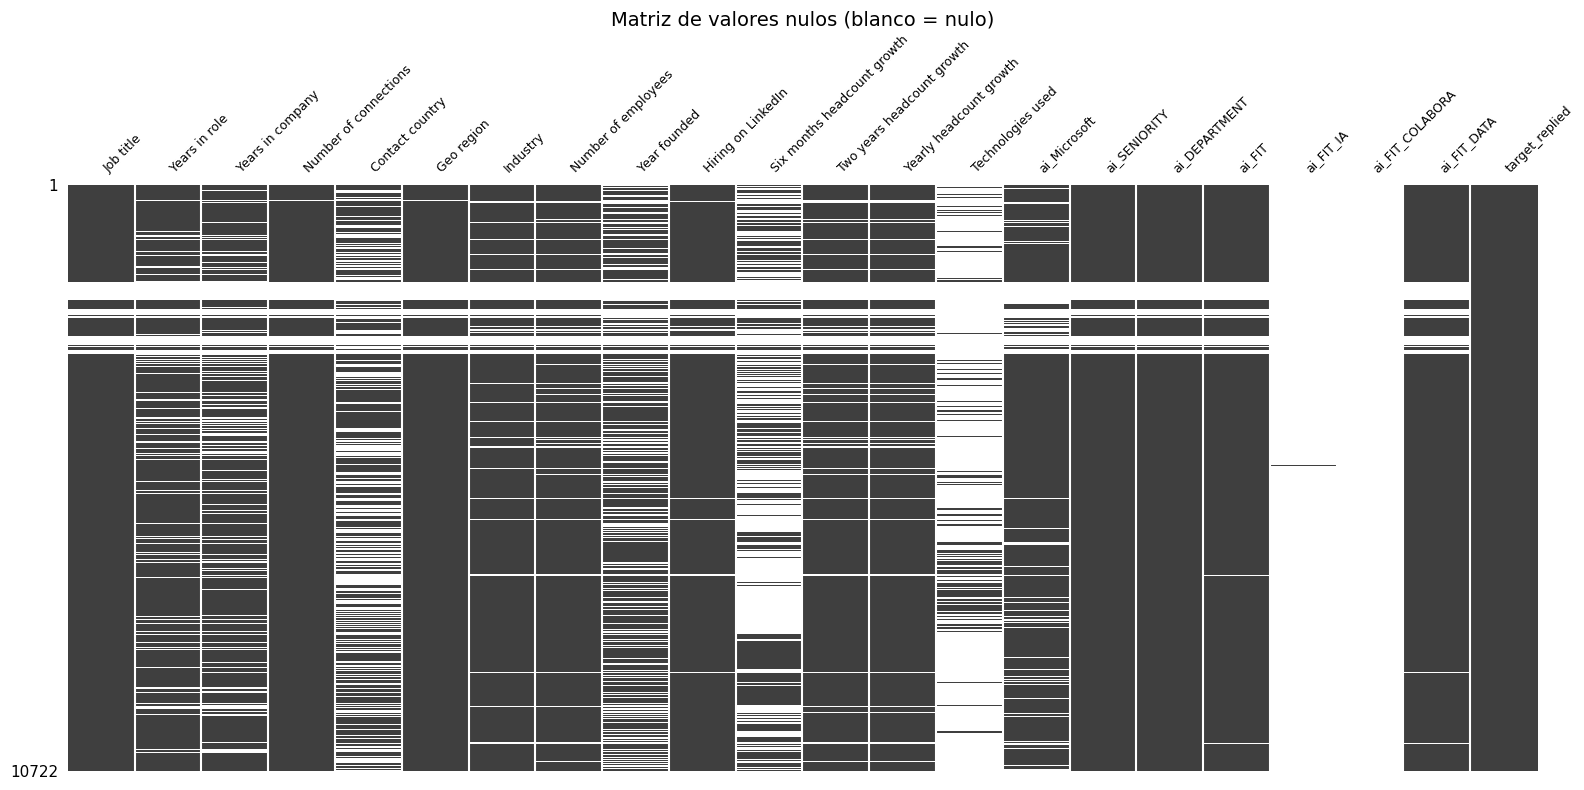

In [17]:
# 2. Visualizacion de nulos con missingno
import missingno as msno
import matplotlib.pyplot as plt

# Seleccionar columnas de features (excluir IDs, texto largo, y targets)
feature_cols = [
    'Job title', 'Years in role', 'Years in company', 'Number of connections',
    'Contact country', 'Geo region', 'Gender',
    'Industry', 'Number of employees', 'Revenue', 'Year founded',
    'Hiring on LinkedIn',
    'Six months headcount growth', 'Two years headcount growth', 'Yearly headcount growth',
    'Technologies used', 'ai_Microsoft',
    'ai_SENIORITY', 'ai_DEPARTMENT',
    'ai_FIT', 'ai_FIT_IA', 'ai_FIT_COLABORA', 'ai_FIT_INFRA',
    'ai_FIT_DATA', 'ai_FIT_WORKPLACE', 'ai_FIT_MAITE',
    'ai_Contact_score', 'ai_Company_score',
    'target_replied',
]
existing_feature_cols = [c for c in feature_cols if c in df.columns]

fig, ax = plt.subplots(figsize=(16, 8))
msno.matrix(df[existing_feature_cols], ax=ax, fontsize=9, sparkline=False)
plt.title('Matriz de valores nulos (blanco = nulo)', fontsize=14)
plt.tight_layout()
plt.show()

In [18]:
# 3. Valores unicos de columnas categoricas clave
cat_cols = ['ai_SENIORITY', 'ai_DEPARTMENT', 'ai_TYPE_OF_CONTACT',
            'Contact country', 'Gender']

for col in cat_cols:
    if col in df.columns and df[col].notna().any():
        print(f'\n=== {col} (top 10) ===')
        print(df[col].value_counts().head(10))


=== ai_SENIORITY (top 10) ===
ai_SENIORITY
DIRECTOR    2942
LEAD        1934
JR          1832
MANAGER     1409
CLEVEL      1207
OWNER        354
OTHER        174
VP            81
TRAINEE       18
Name: count, dtype: int64

=== ai_DEPARTMENT (top 10) ===
ai_DEPARTMENT
IT             3669
OPerations     2164
Other          2020
Sales & MKT    1251
Finance         826
Name: count, dtype: int64

=== ai_TYPE_OF_CONTACT (top 10) ===
ai_TYPE_OF_CONTACT
🤝 Referer           3665
🎩 INFLUENCER        2017
🤝 Referidor          979
🚀 Champion-Buyer     683
🎩📞 Decisor           521
🚀 Champion           339
🛑 NULL               175
🎩 Decisor 📞           71
🎩 Decisor             43
🎩 Decisor - 📞          4
Name: count, dtype: int64

=== Contact country (top 10) ===
Contact country
Spain         5768
España           7
Chile            6
Mexico           6
Portugal         4
Peru             4
Montserrat       3
France           3
Brazil           2
Colombia         2
Name: count, dtype: int64


In [19]:
# 4. Estadisticas de columnas numericas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Excluir targets y binarias
numeric_stats = [c for c in numeric_cols if not c.startswith('target_')]
if numeric_stats:
    print('=== Estadisticas numericas ===')
    print(df[numeric_stats].describe().round(2).to_string())

=== Estadisticas numericas ===
       Years in company  Years in role  Number of connections   Company URN  Number of employees  Year founded  Hiring on LinkedIn  Six months headcount growth  Two years headcount growth  Yearly headcount growth  ai_Microsoft  reply_message_number
count           8351.00        8803.00                9945.00  9.558000e+03              9388.00       6839.00             9745.00                      4717.00                      9369.0                  9369.00       9116.00                819.00
mean               9.27           5.95                1161.74  1.225510e+07              2278.10       1959.91                0.41                         1.60                        17.3                     6.39          0.78                  4.85
std                9.90           7.07                2215.49  2.268408e+07              7990.10         87.52                0.49                         4.47                        40.4                    30.13          

In [20]:
# 5. Distribucion del target
print('=== Distribucion del target ===')
print(f'target_replied = 0 (no respondio): {(df["target_replied"] == 0).sum():,} ({(df["target_replied"] == 0).mean():.1%})')
print(f'target_replied = 1 (respondio):    {(df["target_replied"] == 1).sum():,} ({(df["target_replied"] == 1).mean():.1%})')
print(f'\nPor canal:')
print(f'  LinkedIn: {df["target_replied_linkedin"].sum()} ({df["target_replied_linkedin"].mean():.1%})')
print(f'  Email:    {df["target_replied_email"].sum()} ({df["target_replied_email"].mean():.1%})')

=== Distribucion del target ===
target_replied = 0 (no respondio): 9,881 (92.2%)
target_replied = 1 (respondio):    841 (7.8%)

Por canal:
  LinkedIn: 536 (5.0%)
  Email:    305 (2.8%)


---
## 1.7 Selecciónar columnas finales

Organizamos las columnas por categoria y eliminamos las que ya no necesitamos.

In [21]:
# Definir columnas finales por categoria
cols_id = ['LinkedIn profile ID', 'Company URN', 'Company name',
           'First name', 'Last name', 'Full name']

cols_campaign = ['Campaigns', 'Campaign engagement status']

cols_raw_contact = [
    'Job title', 'Years in role', 'Years in company',
    'Number of connections', 'Contact country', 'Geo region',
    'Gender', 'Profile bio', 'Professional email',
]

cols_raw_company = [
    'Industry', 'Number of employees', 'Revenue', 'Year founded',
    'Hiring on LinkedIn',
    'Six months headcount growth', 'Two years headcount growth', 'Yearly headcount growth',
]

cols_tech = ['Technologies used']

cols_linkedin_activity = ['Last LinkedIn post date', 'Jobs posted from LinkedIn']

cols_ai = [
    'ai_SENIORITY', 'ai_DEPARTMENT',
    'ai_FIT', 'ai_FIT_IA', 'ai_FIT_COLABORA',
    'ai_FIT_INFRA', 'ai_FIT_DATA', 'ai_FIT_WORKPLACE', 'ai_FIT_MAITE',
    'ai_Microsoft',
]

cols_text_nlp = ['ai_CONTACT_REPORT', 'ai_COMPANY_REPORT', 'ai_MOMENTUM']

cols_type_of_contact = [
    'ai_TYPE_OF_CONTACT', 'ai_TYPE_OF_CONTACT_COLABORA', 'ai_TYPE_OF_CONTACT_IA',
    'ai_TYPE_OF_CONTACT_INFRA', 'ai_TYPE_OF_CONTACT_MAITE',
    'ai_TYPE_OF_CONTACT_WORKPLACE', 'ai_TYPE_OF_CONTACT_DATA',
    'ai_TYPE_OF_CONTACT_AJUSTAR',
]

cols_engagement = ['Conversation tags']

cols_target = ['target_replied', 'target_positive', 'target_replied_linkedin', 'target_replied_email', 'reply_message_number']

# Todas las columnas en orden
all_cols = (cols_id + cols_campaign + cols_raw_contact + cols_raw_company +
            cols_tech + cols_linkedin_activity + cols_ai + cols_type_of_contact +
            cols_text_nlp + cols_engagement + cols_target + ['_was_contacted'])

# Verificar que todas existen
missing_cols = [c for c in all_cols if c not in df.columns]
if missing_cols:
    print(f'ATENCION: Columnas no encontradas: {missing_cols}')
else:
    print(f'Todas las {len(all_cols)} columnas encontradas')

# Seleccionar y reordenar
existing_cols = [c for c in all_cols if c in df.columns]
df = df[existing_cols]
print(f'\nDataset final: {df.shape[0]:,} filas x {df.shape[1]} columnas')


ATENCION: Columnas no encontradas: ['Gender', 'Revenue', 'Jobs posted from LinkedIn', 'ai_FIT_INFRA', 'ai_FIT_WORKPLACE', 'ai_FIT_MAITE', 'ai_TYPE_OF_CONTACT_AJUSTAR']

Dataset final: 10,722 filas x 49 columnas


---
## 1.8 Diccionario de datos

Referencia completa de cada columna, su nombre original, tipo y origen.

In [22]:
data_dict = [
    # IDs
    ('LinkedIn profile ID', 'LinkedIn profile ID', 'ID', 'Raw', 'Identificador unico del contacto en LinkedIn'),
    ('Company URN', 'Company URN', 'ID', 'Raw', 'Identificador LinkedIn de la empresa'),
    ('Company name', 'Company name', 'ID', 'Raw', 'Nombre de la empresa'),
    ('First name', 'First name', 'text', 'Raw', 'Nombre del contacto'),
    ('Last name', 'Last name', 'text', 'Raw', 'Apellido del contacto'),
    ('Full name', 'Full name', 'text', 'Raw', 'Nombre completo'),
    # Campaign
    ('Campaigns', 'Campaigns', 'text', 'Raw', 'Lista de campañas en las que participo el contacto'),
    ('Campaign engagement status', 'Campaign engagement status', 'categorical', 'Raw', 'Estado de engagement (Replied/Sent/Added)'),
    # Raw contact
    ('Job title', 'Job title', 'text', 'Raw', 'Titulo profesional en LinkedIn'),
    ('Years in role', 'Years in role', 'numeric', 'Raw', 'Anos en el puesto actual'),
    ('Years in company', 'Years in company', 'numeric', 'Raw', 'Anos en la empresa actual'),
    ('Number of connections', 'Number of connections', 'numeric', 'Raw', 'Numero de conexiones LinkedIn'),
    ('Contact country', 'Contact country', 'categorical', 'Raw', 'Pais del contacto'),
    ('Geo region', 'Geo region', 'categorical', 'Raw', 'Region geografica'),
    ('Gender', 'Gender', 'categorical', 'Raw', 'Genero'),
    ('Profile bio', 'Profile bio', 'text', 'Raw', 'Biografia LinkedIn'),
    ('Professional email', 'Professional email', 'text', 'Raw', 'Email profesional (para feature binaria has_email)'),
    # Raw company
    ('Industry', 'Industry', 'categorical', 'Raw', 'Sector de la empresa'),
    ('Number of employees', 'Number of employees', 'numeric', 'Raw', 'Numero de empleados'),
    ('Revenue', 'Revenue', 'numeric', 'Raw', 'Facturacion'),
    ('Year founded', 'Year founded', 'numeric', 'Raw', 'Ano de fundacion'),
    ('Hiring on LinkedIn', 'Hiring on LinkedIn', 'binary', 'Raw', 'Si la empresa esta contratando en LinkedIn'),
    ('Six months headcount growth', 'Six months headcount growth', 'numeric', 'Raw', 'Crecimiento plantilla 6 meses (%)'),
    ('Two years headcount growth', 'Two years headcount growth', 'numeric', 'Raw', 'Crecimiento plantilla 2 años (%)'),
    ('Yearly headcount growth', 'Yearly headcount growth', 'numeric', 'Raw', 'Crecimiento plantilla anual (%)'),
    # Tech
    ('Technologies used', 'Technologies used', 'text', 'Raw', 'Lista de tecnologias que usa la empresa'),
    # LinkedIn activity
    ('Last LinkedIn post date', 'Last LinkedIn post date', 'datetime', 'Raw', 'Fecha del ultimo post en LinkedIn'),
    ('Jobs posted from LinkedIn', 'Jobs posted from LinkedIn', 'numeric', 'Raw', 'Numero de ofertas publicadas en LinkedIn'),
    # AI-enriched
    ('ai_SENIORITY', 'SENIORITY', 'categorical', 'AI-enriched', 'Nivel jerarquico (C-Level, Director, Manager, etc.)'),
    ('ai_DEPARTMENT', 'DEPARTMENT', 'categorical', 'AI-enriched', 'Departamento (IT, Operations, HR, etc.)'),
    ('ai_FIT', 'FIT', 'categorical', 'AI-enriched', 'Puntuacion general de fit'),
    ('ai_FIT_IA', 'FIT IA', 'categorical', 'AI-enriched', 'Fit para Soluciones AI (Azure AI, Copilot)'),
    ('ai_FIT_COLABORA', 'FIT COLABORA', 'categorical', 'AI-enriched', 'Fit para Collaboration Hub (Teams, SharePoint)'),
    ('ai_FIT_INFRA', 'FIT INFRA', 'categorical', 'AI-enriched', 'Fit para Infraestructuras Cloud (Azure)'),
    ('ai_FIT_DATA', 'FIT DATA', 'categorical', 'AI-enriched', 'Fit para Data Analytics (Power BI, Fabric)'),
    ('ai_FIT_WORKPLACE', 'FIT WORKPLACE', 'categorical', 'AI-enriched', 'Fit para Digital Workplace (M365)'),
    ('ai_FIT_MAITE', 'FIT MAITE', 'categorical', 'AI-enriched', 'Fit para Gobernanza IT (Intune, Entra ID, Purview)'),
    ('ai_Microsoft', 'Microsoft?', 'categorical', 'AI-enriched', 'Si la empresa usa tecnologia Microsoft (1=si, 0=no, -1=error)'),
    ('ai_TYPE_OF_CONTACT', 'TYPE OF CONTACT', 'categorical', 'AI-enriched', 'Tipo de contacto: Decisor, Champion, Influencer, Referer, NULL'),
    ('ai_TYPE_OF_CONTACT_COLABORA', 'TYPE OF CONTACT COLABORA', 'categorical', 'AI-enriched', 'Tipo de contacto para producto COLABORA'),
    ('ai_TYPE_OF_CONTACT_IA', 'TYPE OF CONTACT IA', 'categorical', 'AI-enriched', 'Tipo de contacto para producto IA'),
    ('ai_TYPE_OF_CONTACT_INFRA', 'TYPE OF CONTACT INFRA', 'categorical', 'AI-enriched', 'Tipo de contacto para producto INFRA'),
    ('ai_TYPE_OF_CONTACT_MAITE', 'TYPE OF CONTACT MAITE', 'categorical', 'AI-enriched', 'Tipo de contacto para producto MAITE'),
    ('ai_TYPE_OF_CONTACT_WORKPLACE', 'TYPE OF CONTACT WORKPLACE', 'categorical', 'AI-enriched', 'Tipo de contacto para producto WORKPLACE'),
    ('ai_TYPE_OF_CONTACT_DATA', 'TYPE OF CONTACT DATA', 'categorical', 'AI-enriched', 'Tipo de contacto para producto DATA'),
    ('ai_TYPE_OF_CONTACT_AJUSTAR', 'TYPE OF CONTACT - Para Ajustar', 'text', 'AI-enriched', 'Tipo de contacto con explicacion para ajuste manual'),
    # NLP text
    ('ai_CONTACT_REPORT', 'CONTACT REPORT', 'text', 'AI-enriched', 'Informe IA sobre el perfil del contacto'),
    ('ai_COMPANY_REPORT', 'COMPANY REPORT', 'text', 'AI-enriched', 'Informe IA sobre la empresa'),
    ('ai_MOMENTUM', 'MOMENTUM', 'text', 'AI-enriched', 'Senales de timing (por que contactar ahora)'),
    # Engagement
    ('Conversation tags', 'Conversation tags', 'categorical', 'Raw', 'Etiquetas de la conversacion'),
    # Targets
    ('target_replied', '-', 'binary', 'Created', 'Variable objetivo: 1 si respondio, 0 si no'),
    ('target_replied_linkedin', '-', 'binary', 'Created', '1 si respondio por LinkedIn'),
    ('target_replied_email', '-', 'binary', 'Created', '1 si respondio por email'),
    ('reply_message_number', '-', 'numeric', 'Created', 'Numero de mensaje en el que respondio (extraido del status)'),
]

dict_df = pd.DataFrame(data_dict, columns=['Columna', 'Nombre original', 'Tipo', 'Origen', 'Descripcion'])
print(f'Diccionario de datos: {len(dict_df)} columnas documentadas')
dict_df

Diccionario de datos: 54 columnas documentadas


,Columna,Nombre original,Tipo,Origen,Descripcion
0,LinkedIn profile ID,LinkedIn profile ID,ID,Raw,Identificador unico del contacto en LinkedIn
1,Company URN,Company URN,ID,Raw,Identificador LinkedIn de la empresa
2,Company name,Company name,ID,Raw,Nombre de la empresa
3,First name,First name,text,Raw,Nombre del contacto
4,Last name,Last name,text,Raw,Apellido del contacto
5,Full name,Full name,text,Raw,Nombre completo
6,Campaigns,Campaigns,text,Raw,Lista de campañas en las que participo el cont...
7,Campaign engagement status,Campaign engagement status,categorical,Raw,Estado de engagement (Replied/Sent/Added)
8,Job title,Job title,text,Raw,Titulo profesional en LinkedIn
9,Years in role,Years in role,numeric,Raw,Anos en el puesto actual


---
## 1.9 Guardar outputs

Guardamos los datasets en formato **Parquet** (formato binario columnar):
- 10x más compacto que CSV
- 10x más rápido de cargar
- Preserva tipos de datos

In [23]:
# Separar: contactados (modelado) vs no contactados (pool para scoring)
df_contacted = df[df['_was_contacted']].drop(columns=['_was_contacted']).copy()
df_not_contacted = df[~df['_was_contacted']].drop(columns=['_was_contacted']).copy()

print(f'Contactados (para modelado): {len(df_contacted):,}')
print(f'No contactados (pool): {len(df_not_contacted):,}')
print(f'Tasa de respuesta (contactados): {df_contacted["target_replied"].mean():.1%}')

# 1. Dataset de modelado (solo contactados)
output_path = os.path.join(WORKING_DATA, 'modeling_dataset_raw.parquet')
df_contacted.to_parquet(output_path, index=False)
file_size = os.path.getsize(output_path) / 1e6
print(f'\nGuardado: modeling_dataset_raw.parquet')
print(f'  Tamano: {file_size:.1f} MB')
print(f'  Forma: {df_contacted.shape[0]:,} filas x {df_contacted.shape[1]} columnas')

# 2. Pool de no contactados (para scoring en NB04/NB05)
pool_path = os.path.join(WORKING_DATA, 'not_contacted_pool.parquet')
df_not_contacted.to_parquet(pool_path, index=False)
pool_size = os.path.getsize(pool_path) / 1e6
print(f'\nGuardado: not_contacted_pool.parquet')
print(f'  Tamano: {pool_size:.1f} MB')
print(f'  Forma: {df_not_contacted.shape[0]:,} filas x {df_not_contacted.shape[1]} columnas')

Contactados (para modelado): 5,987
No contactados (pool): 4,735
Tasa de respuesta (contactados): 14.0%

Guardado: modeling_dataset_raw.parquet
  Tamano: 26.9 MB
  Forma: 5,987 filas x 48 columnas



Guardado: not_contacted_pool.parquet
  Tamano: 11.4 MB
  Forma: 4,735 filas x 48 columnas


In [24]:
# 2. Conversation level analytics (para analisis de funnel/timing en NB02)
analytics = pd.read_csv(
    os.path.join(RAW_DATA, 'conversation_level_analytics_ES.csv'),
    encoding='utf-8-sig'
)
analytics['firstMessageAt'] = pd.to_datetime(analytics['firstMessageAt'])
analytics_path = os.path.join(WORKING_DATA, 'conversation_analytics_ES.parquet')
analytics.to_parquet(analytics_path, index=False)
print(f'Guardado: conversation_analytics_ES.parquet ({len(analytics):,} filas)')

# 3. Daily analytics
daily = pd.read_csv(
    os.path.join(RAW_DATA, 'daily_comprehensive_analytics_ES.csv'),
    encoding='utf-8-sig'
)
daily['date'] = pd.to_datetime(daily['date'])
daily_path = os.path.join(WORKING_DATA, 'daily_analytics_ES.parquet')
daily.to_parquet(daily_path, index=False)
print(f'Guardado: daily_analytics_ES.parquet ({len(daily)} filas)')

# 4. Replies analytics
replies = pd.read_csv(
    os.path.join(RAW_DATA, 'replies_analytics_ES.csv'),
    encoding='utf-8-sig'
)
replies['timestamp'] = pd.to_datetime(replies['timestamp'])
replies_path = os.path.join(WORKING_DATA, 'replies_analytics_ES.parquet')
replies.to_parquet(replies_path, index=False)
print(f'Guardado: replies_analytics_ES.parquet ({len(replies)} filas)')

Guardado: conversation_analytics_ES.parquet (11,517 filas)
Guardado: daily_analytics_ES.parquet (310 filas)
Guardado: replies_analytics_ES.parquet (13 filas)


---
## Resumen

### Qué hemos hecho:
1. Cargado `contacts_table_ES.csv` como tabla base (48 columnas de 373, incluyendo TYPE OF CONTACT)
2. Creado la variable objetivo `target_replied` desde `Campaign engagement status`
3. Identificado contactos sin mensajes enviados (Added to Campaign, sin campaña)
4. Marcado contactos no contactados para separación al final del notebook
5. Excluido contactos no válidos (Microsoft?=-1, FIT=NO)
6. Extraido `reply_message_number` del status de engagement
7. Eliminado duplicados de LinkedIn profile ID
8. Renombrado columnas AI con prefijo `ai_` para trazabilidad
9. Convertido tipos de datos (numericos, fechas)
10. Verificado calidad: nulos, duplicados, distribución del target
11. Construido diccionario de datos
12. Guardado dataset de modelado (5,987 contactados) y pool de no contactados (4,735)

### Cambios respecto a versiones anteriores:
- **Contact Score y Company Score excluidos del dataset**: se sustituyen por TYPE OF CONTACT, que describe el rol del contacto en el proceso de compra (Decisor, Champion, Influencer) y es más relevante para predecir la respuesta que un score generico (High/Medium/Low)
- **Contactos sin mensajes separados como pool**: no son falsos negativos válidos, pero se guardan como candidatos para el lead scorer
- **Microsoft?=-1 y FIT=NO excluidos**: contactados por error, no son prospectos válidos
- **reply_message_number**: nuevo campo para analizar en que mensaje responden los contactos

### Decisión arquitectural: contacts_table como tabla base
- `conversation_level_analytics` usa un `contactId` interno de Enginy que no existe en la tabla de contactos
- `contacts_table_ES` contiene tanto las features como la información de engagement en una sola tabla
- La granularidad contacto (vs conversación) es más adecuada para predecir QUIEN contactar
- Los datos de conversación se guardan por separado para análisis de funnel y timing

### Que NO hemos hecho (se hara en notebooks posteriores):
- Feature engineering (NB03)
- NLP sobre campos de texto (NB03)
- Enrichment externo (NB03)
- Imputacion de nulos (NB03)
- Modelado (NB04)

### Próximo paso: NB02 - Análisis Exploratorio de Datos

In [25]:
# Resumen final
print('=' * 60)
print('RESUMEN NOTEBOOK 01')
print('=' * 60)
print(f'Dataset de modelado: {df_contacted.shape[0]:,} filas x {df_contacted.shape[1]} columnas')
print(f'  Positivos (target=1): {df_contacted["target_replied"].sum():,} ({df_contacted["target_replied"].mean():.1%})')
print(f'  Negativos (target=0): {(df_contacted["target_replied"]==0).sum():,} ({(df_contacted["target_replied"]==0).mean():.1%})')
print(f'\nPool de no contactados: {len(df_not_contacted):,} filas')
print(f'\nColumnas por origen:')
print(f'  IDs:              {len(cols_id)}')
print(f'  Campaign info:    {len(cols_campaign)}')
print(f'  Raw contact:      {len(cols_raw_contact)}')
print(f'  Raw company:      {len(cols_raw_company)}')
print(f'  Tech:             {len(cols_tech)}')
print(f'  LinkedIn act.:    {len(cols_linkedin_activity)}')
print(f'  AI-enriched:      {len(cols_ai)}')
print(f'  Type of Contact:  {len(cols_type_of_contact)}')
print(f'  Text (NLP):       {len(cols_text_nlp)}')
print(f'  Engagement:       {len(cols_engagement)}')
print(f'  Targets:          {len(cols_target)}')
print(f'\nArchivos generados:')
for f in sorted(os.listdir(WORKING_DATA)):
    fpath = os.path.join(WORKING_DATA, f)
    if os.path.isfile(fpath):
        size = os.path.getsize(fpath) / 1e6
        print(f'  {f}: {size:.1f} MB')

RESUMEN NOTEBOOK 01
Dataset de modelado: 5,987 filas x 48 columnas
  Positivos (target=1): 841 (14.0%)
  Negativos (target=0): 5,146 (86.0%)

Pool de no contactados: 4,735 filas

Columnas por origen:
  IDs:              6
  Campaign info:    2
  Raw contact:      9
  Raw company:      8
  Tech:             1
  LinkedIn act.:    2
  AI-enriched:      10
  Type of Contact:  8
  Text (NLP):       3
  Engagement:       1
  Targets:          5

Archivos generados:
  conversation_analytics_ES.parquet: 0.3 MB
  daily_analytics_ES.parquet: 0.0 MB
  metrics.json: 0.0 MB
  modeling_dataset_final.parquet: 25.3 MB
  modeling_dataset_raw.parquet: 26.9 MB
  not_contacted_pool.parquet: 11.4 MB
  not_contacted_pool_scored.parquet: 11.4 MB
  predictions.parquet: 25.4 MB
  replies_analytics_ES.parquet: 0.0 MB
